In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
customers = pd.read_csv('customers_sales.csv')
customers.join_date = pd.to_datetime(customers.join_date, errors= 'coerce')
products_sales= pd.read_csv('products_sales.csv')
stores_sales= pd.read_csv('store_sales.csv')

In [5]:
#Find how many customers have joined through years 
customers['year_join'] = customers.join_date.dt.year 
joind_in = customers.groupby('year_join')['customer_id'].count()
joind_in


year_join
2021     8238
2022    10002
2023     9886
2024     9993
2025    10088
2026     1793
Name: customer_id, dtype: int64

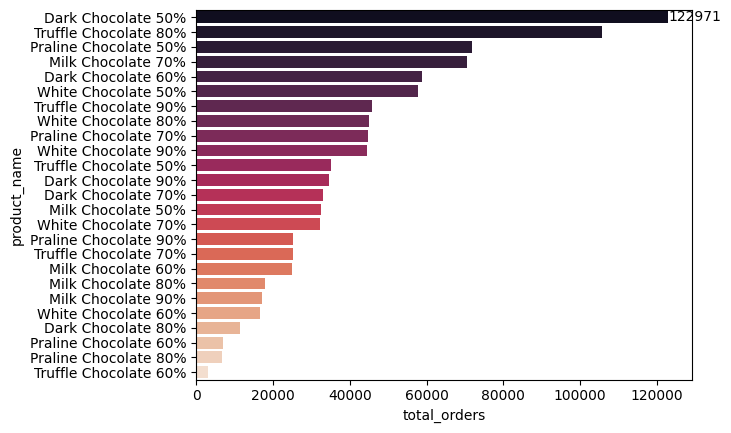

In [47]:
#Find the total customers for each product
count_products = customers.groupby('product_name')['total_orders'].sum().sort_values(ascending= False).reset_index()

chart= sns.barplot(data= count_products, x= 'total_orders', y= 'product_name', palette='rocket', hue= 'product_name')

chart.bar_label(chart.containers[0])
plt.show()
# count_products.plot.pie(x= count_products['total_orders'], labels= count_products['product_name'], autopct= '%1.0f%%', subplots=True)

array([<Axes: >], dtype=object)

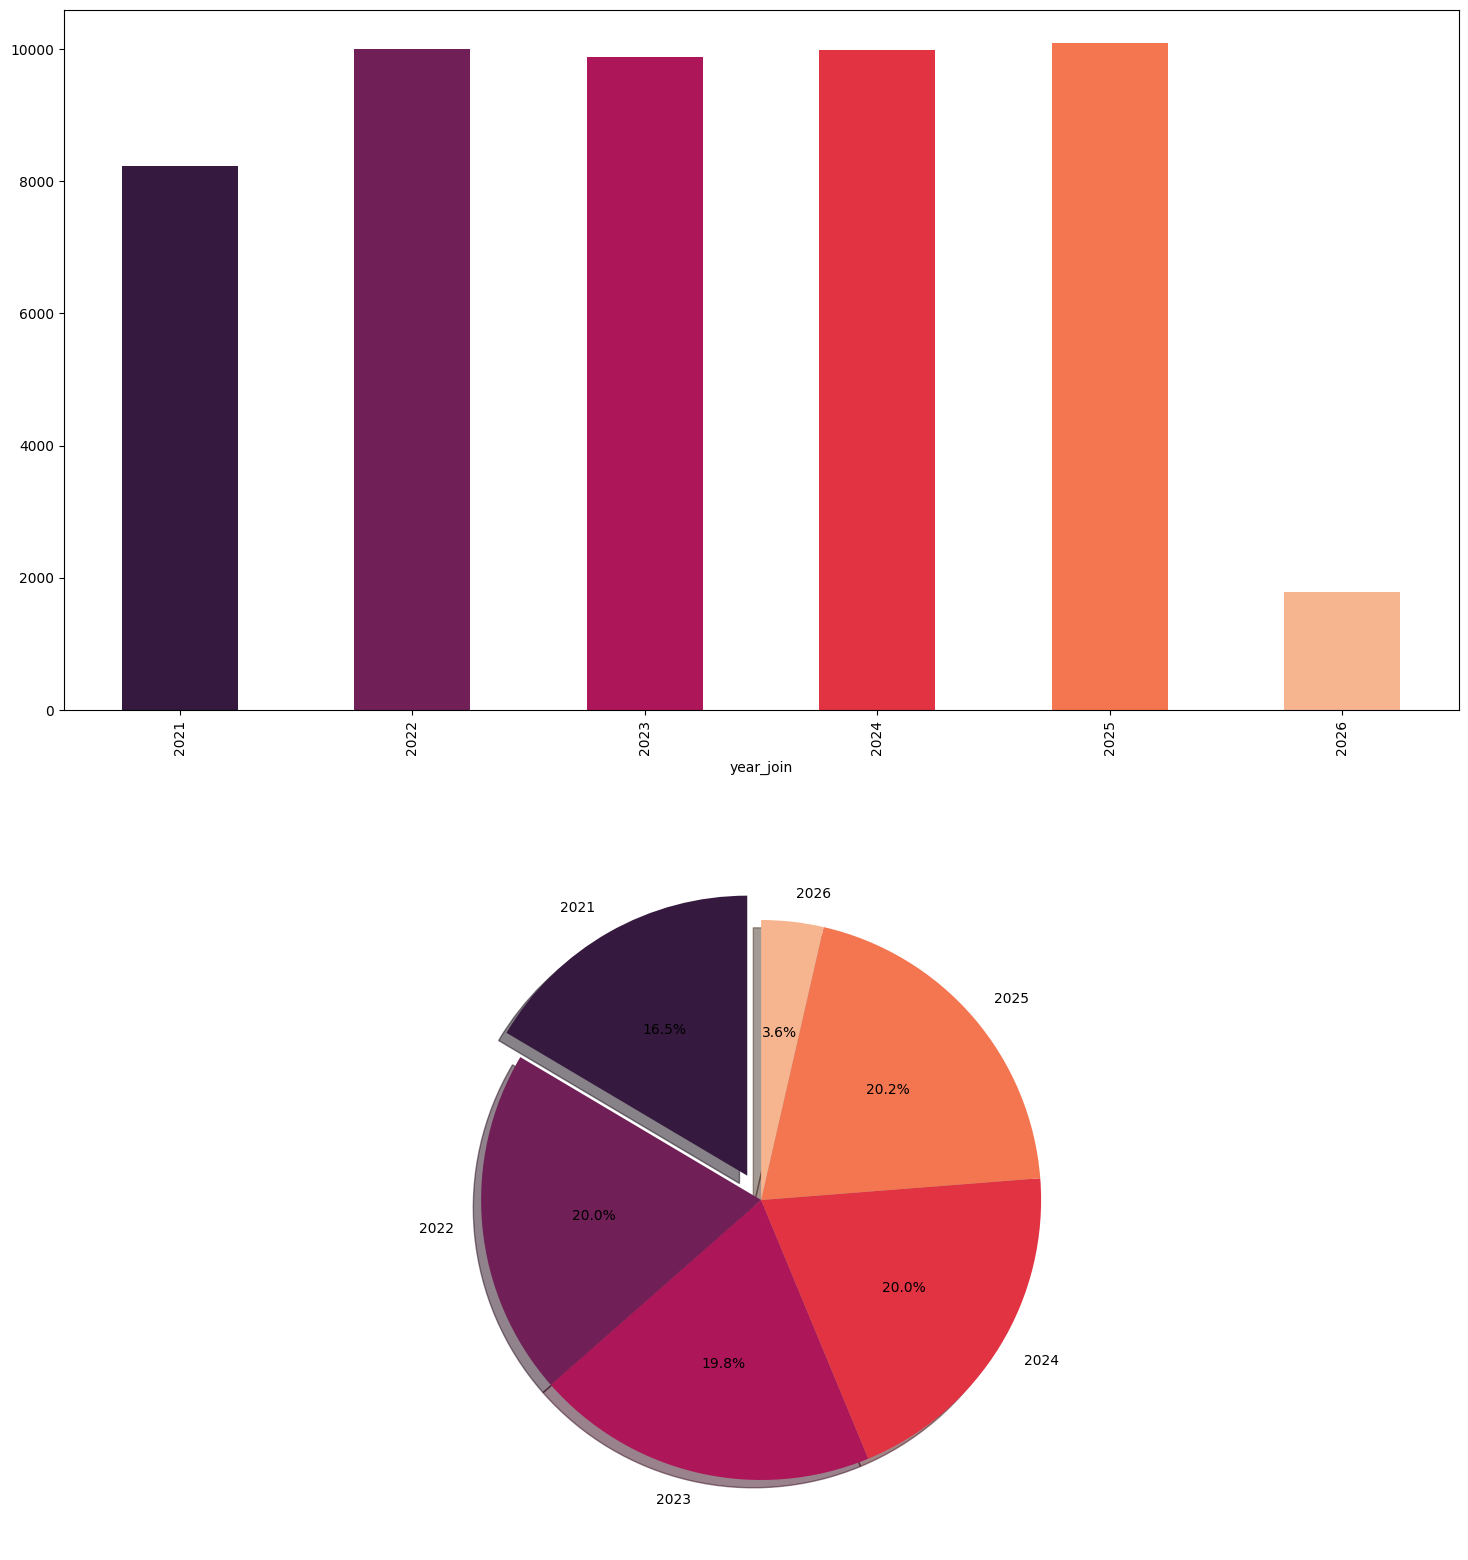

In [ ]:
#The customers that joined anualy
fig, axes = plt.subplots(ncols=1, nrows=2, figsize= (18,20))
out= (0.1, 0, 0, 0, 0, 0)
sns_colors= sns.color_palette('rocket', 6)
joind_in.plot(kind= 'bar', ax= axes[0],  color= sns_colors)
joind_in.plot.pie(x= joind_in.values,labels=joind_in.index, autopct= '%1.1f%%', startangle= 90, ax= axes[1],subplots= True, ylabel='', colors= sns_colors,shadow= True, explode = out)

C:\Users\Fatima\AppData\Local\Temp\ipykernel_33608\1222599514.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data= customers,x= 'customer_retention', y= 'total_orders', palette= 'GnBu', alpha= 0.7)


<Axes: xlabel='customer_retention', ylabel='total_orders'>

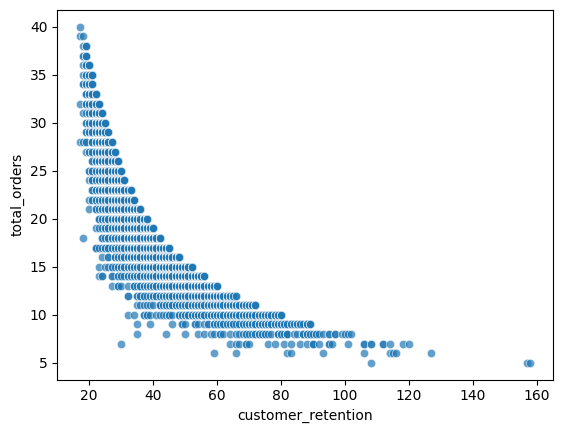

In [ ]:
#find the relation between customers and thier orders 

sns.scatterplot(data= customers,x= 'customer_retention', y= 'total_orders', palette= 'GnBu', alpha= 0.7)

<Axes: xlabel='loyalty_member', ylabel='customer_retention'>

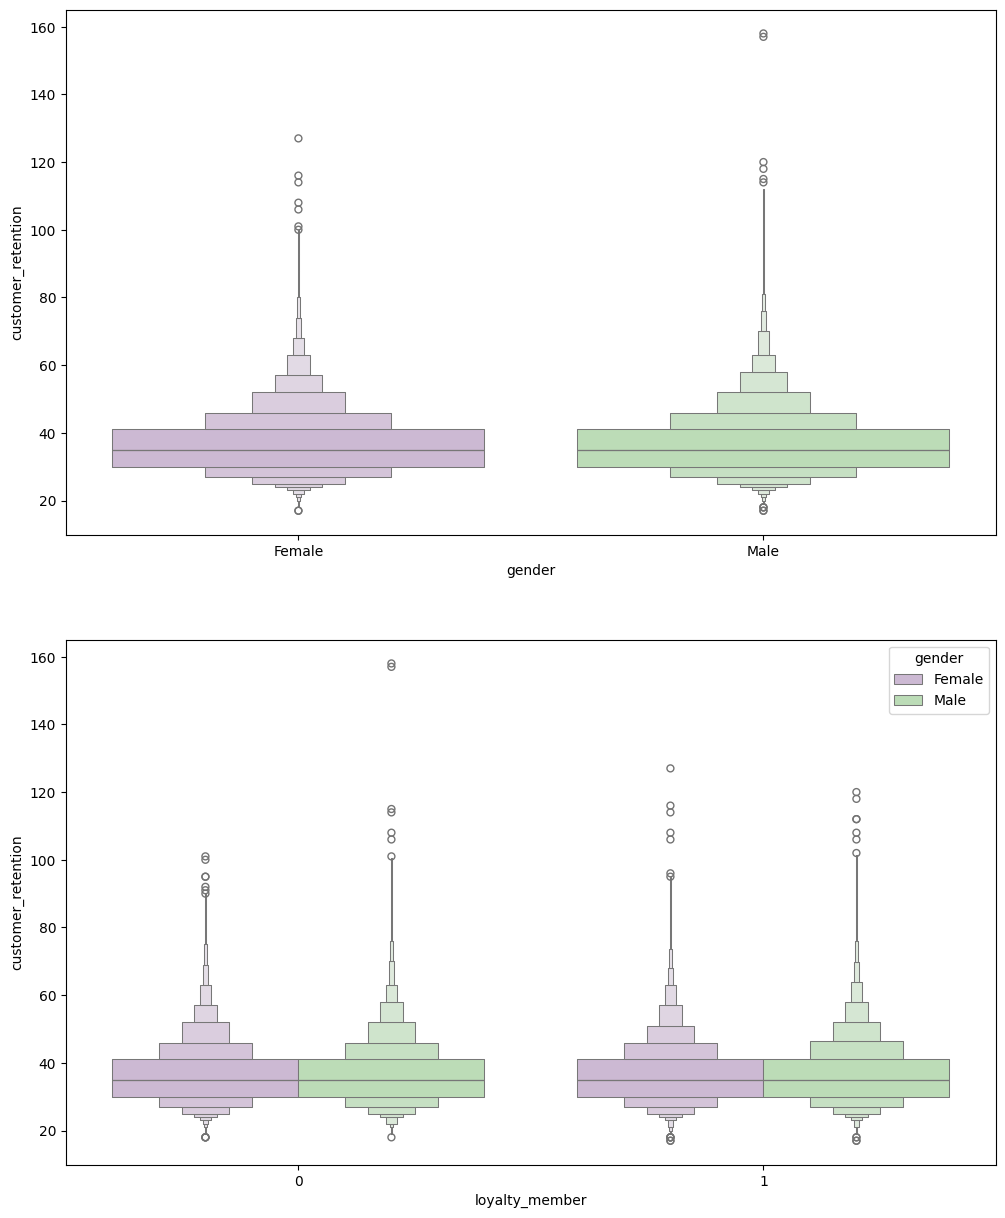

In [29]:
# apply boxplot to show 
fig, axes = plt.subplots(ncols=1, nrows=2,figsize=(12,15))
sns.boxenplot(data= customers, x= 'gender', y= 'customer_retention', palette='PRGn', hue= 'gender', ax= axes[0] )
sns.boxenplot(data= customers, x= 'loyalty_member', y= 'customer_retention', palette='PRGn', hue= 'gender', ax= axes[1] )

<Axes: xlabel='a_product', ylabel='customer_retention'>

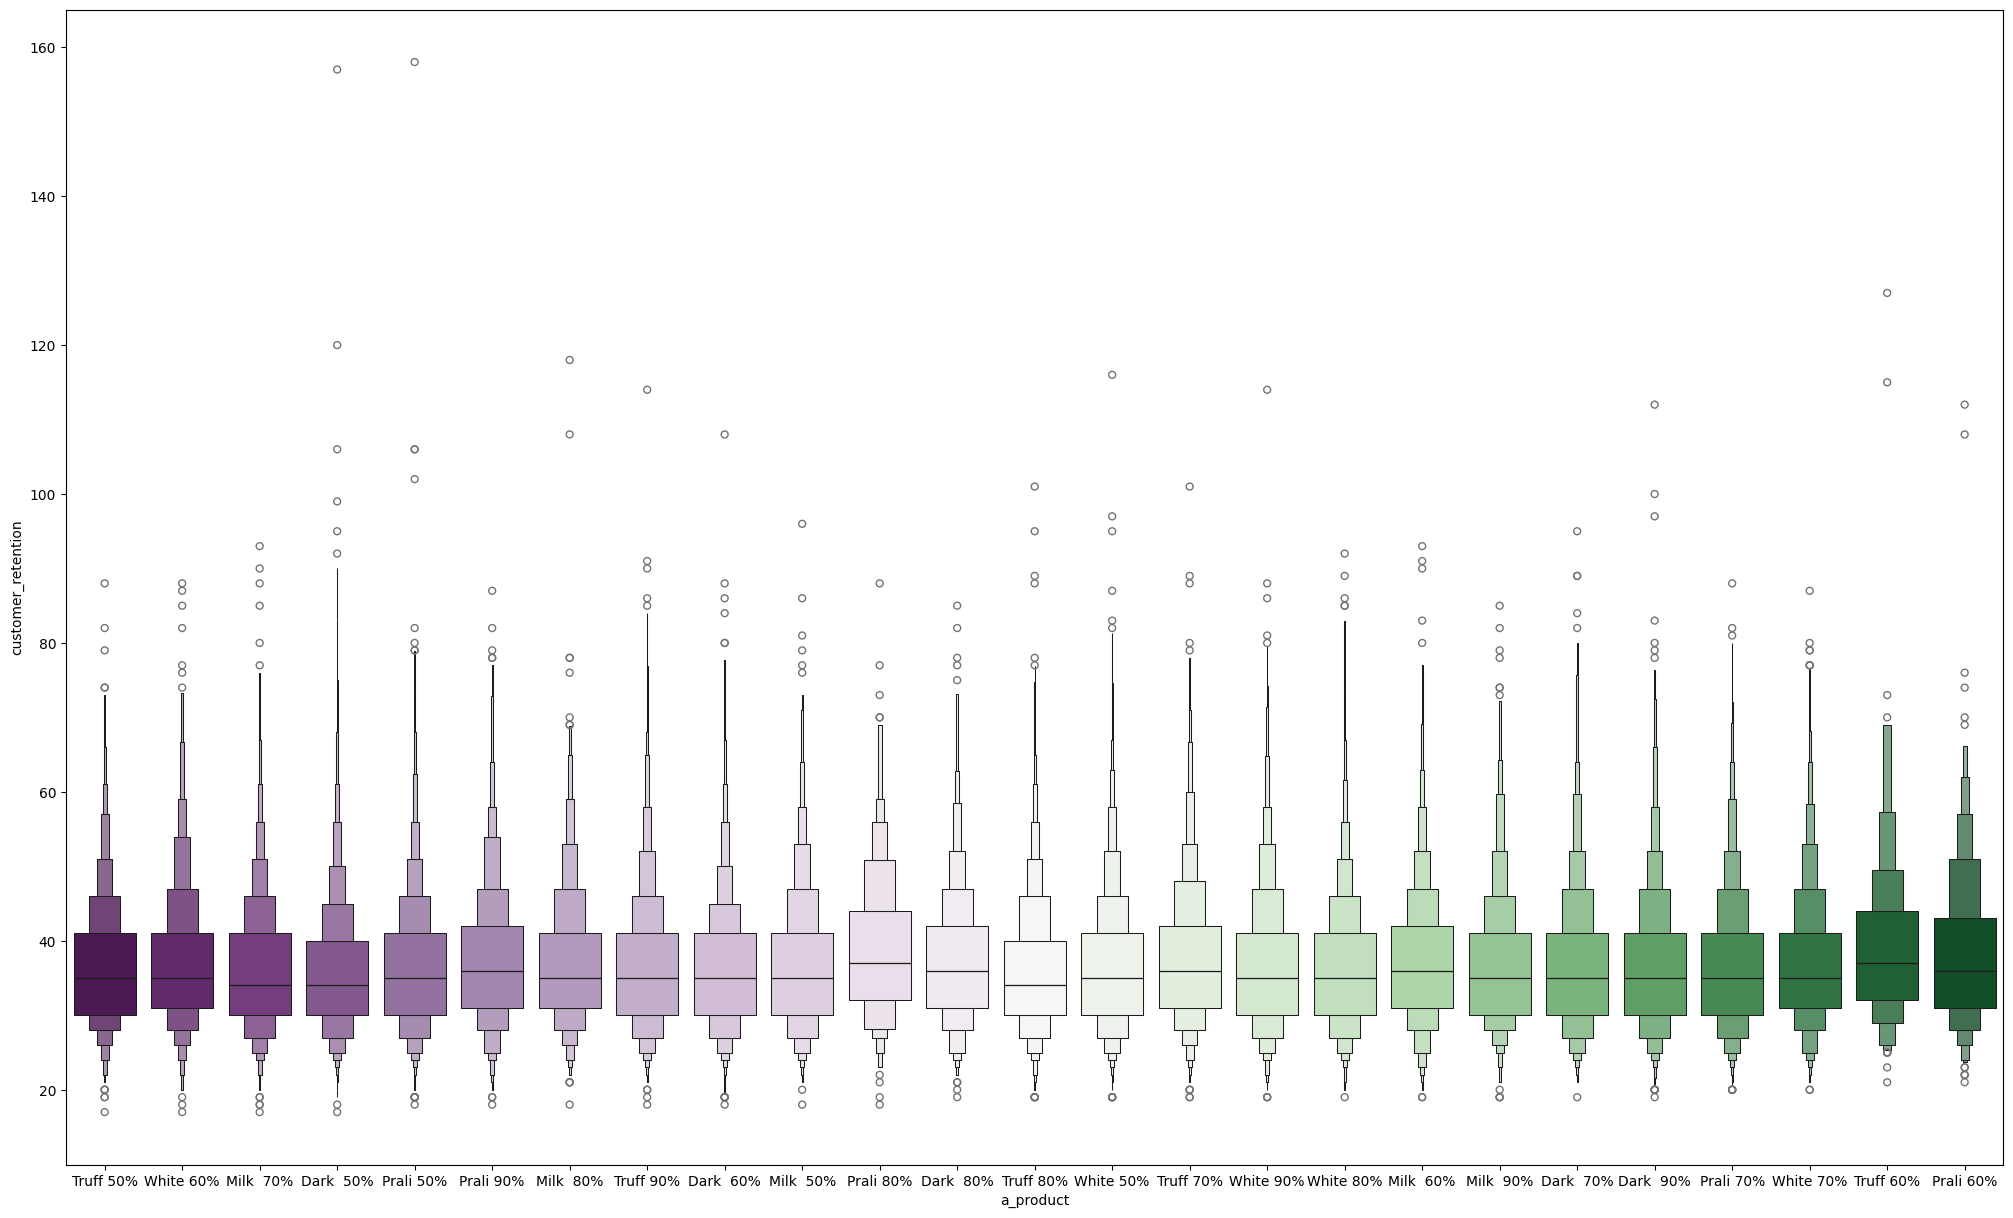

In [30]:
#Striping product names
plt.figure(figsize=(25,15))
customers['a_product'] = customers['product_name'].str.strip().str[:5] + ' '+ customers['product_name'].str.strip().str.split().str[-1]
sns.boxenplot(data= customers, x= 'a_product', y='customer_retention', hue= 'a_product', palette= 'PRGn' )

In [5]:
products_sales.head()

,date,brand,product_name,total_orders,quantity,total_sales,cost,profits
0,01-Apr-2023,Mars,Praline Chocolate 70%,6,15,76.58,42.72,33.86
1,01-Apr-2023,Hershey,Dark Chocolate 70%,7,26,248.66,152.66,96.01
2,01-Apr-2023,Cadbury,White Chocolate 50%,7,24,132.58,78.55,54.03
3,01-Apr-2023,Cadbury,Praline Chocolate 70%,19,63,469.35,282.66,186.68
4,01-Apr-2023,Cadbury,Milk Chocolate 60%,2,4,45.85,31.21,14.64


In [51]:
#Bar chart of brand's product sales
brand_products= products_sales.groupby('brand')['product_name'].count()
brand_products

brand
Cadbury    14616
Ferrero    13152
Godiva     14614
Hershey    14610
Lindt      13882
Mars       13879
Name: product_name, dtype: int64

In [49]:
#Find the total orders of each brand chocolate
brand_products= products_sales.groupby(['brand', 'product_name'])['total_orders'].sum().reset_index().sort_values(by= 'total_orders', ascending=False)
top_brand= brand_products.nlargest(14, "total_orders")
top_brand

,brand,product_name,total_orders
114,Mars,White Chocolate 60%,24628
27,Ferrero,Praline Chocolate 50%,24550
31,Ferrero,Truffle Chocolate 50%,20163
1,Cadbury,Dark Chocolate 60%,20099
0,Cadbury,Dark Chocolate 50%,20038
92,Lindt,Truffle Chocolate 80%,19996
84,Lindt,Milk Chocolate 60%,19832
50,Godiva,Truffle Chocolate 70%,14979
74,Hershey,White Chocolate 50%,14974
15,Cadbury,Truffle Chocolate 90%,14969


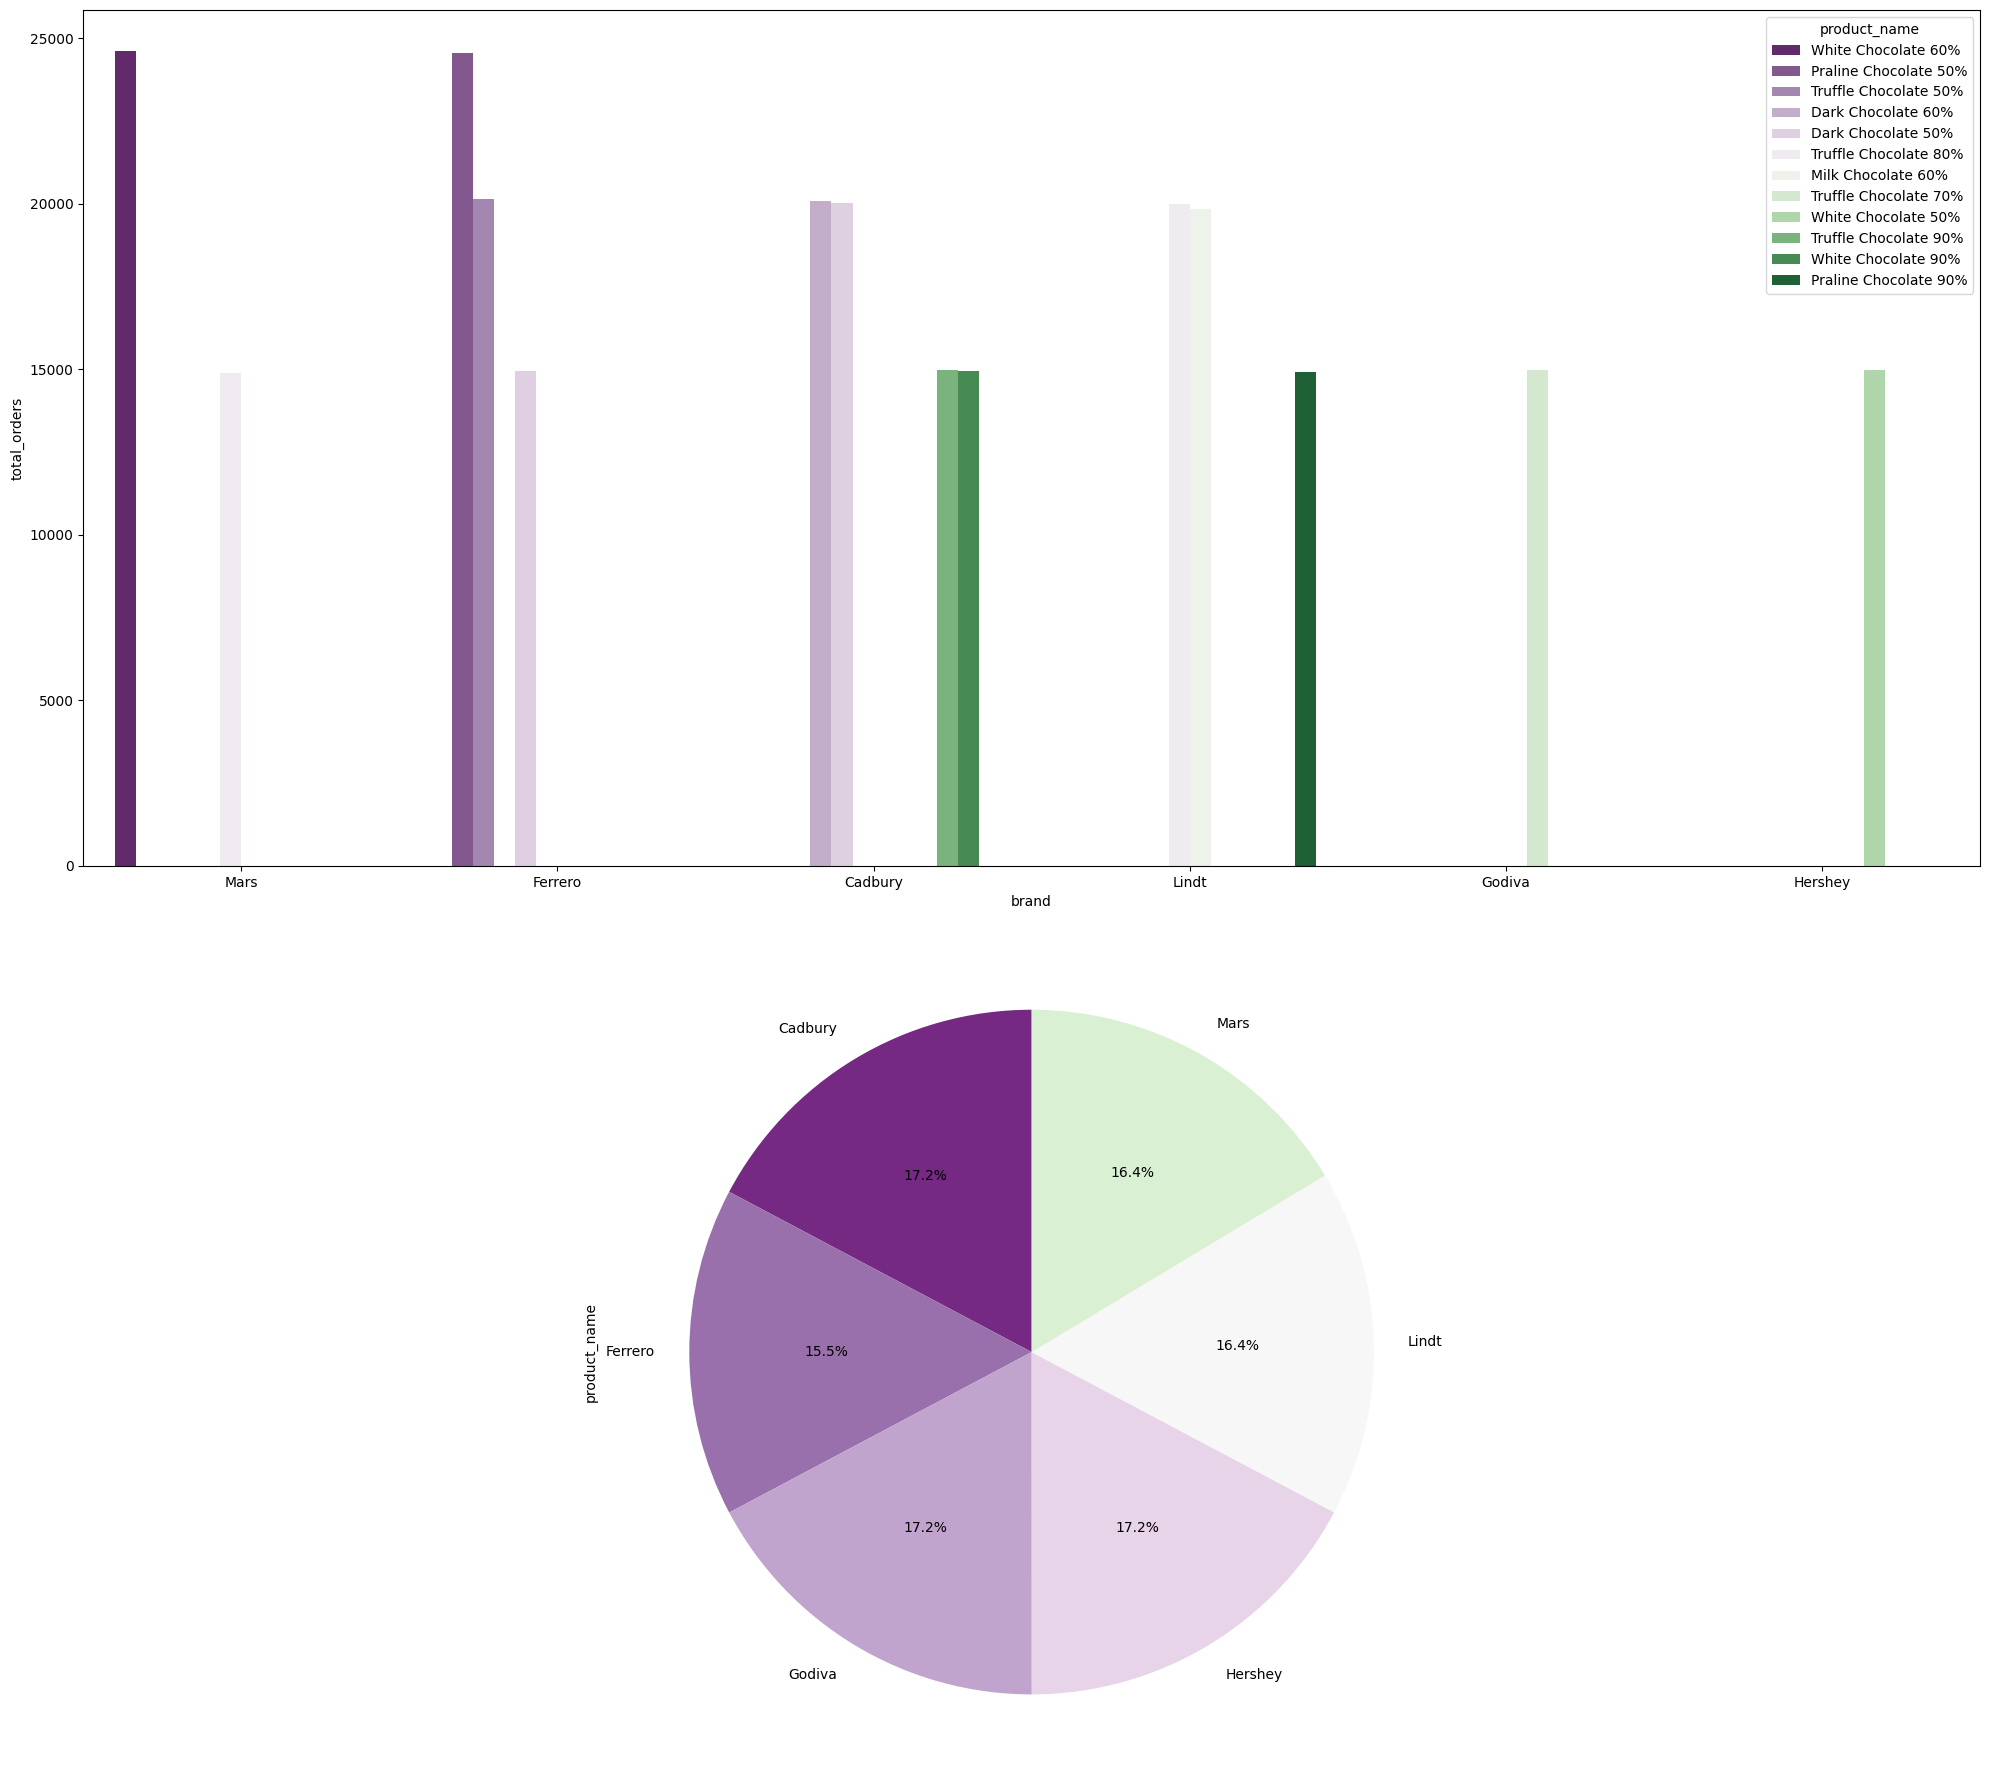

In [52]:
#Top brand for each product
fig, axes = plt.subplots(ncols=1, nrows=2,figsize=(20,18))
pie_color= sns.color_palette('PRGn',9)

sns.barplot(data = top_brand,x= "brand", y="total_orders",  hue= 'product_name', palette= 'PRGn', ax= axes[0])
# Brands total product
brand_products.plot.pie(x=brand_products.values, labels=brand_products.index , autopct= '%1.1f%%', subplots=True, startangle= 90, colors= pie_color, ax= axes[1])

plt.tight_layout()
plt.show()

In [56]:
stores_sales.head()

,date_order,city,store_type,store_name,total_cust,total_orders,quantity,total_sales,total_cost,profits
0,11-2024,New York,Retail,Chocolate Store 1,416,416,1260,10510.96,6297.77,4213.33
1,04-2023,New York,Retail,Chocolate Store 1,418,418,1263,10832.08,6490.57,4341.48
2,03-2024,New York,Retail,Chocolate Store 1,434,434,1303,10884.60,6514.40,4370.33
3,10-2023,New York,Retail,Chocolate Store 1,412,412,1249,10392.08,6218.00,4174.11
4,02-2024,New York,Retail,Chocolate Store 1,397,397,1185,10314.57,6174.25,4140.31


In [136]:
# The sales of each store type
plt.rcParams['font.family'] = 'sans-serif'
stores = stores_sales.groupby(['store_type', 'short_store_name'])[['total_cust', 'quantity', 'total_sales', 'profits']].sum().reset_index()
stores_type_sales = stores_sales.groupby('store_type')[['total_cust', 'quantity', 'total_sales', 'profits']].sum().reset_index()
stores_type_sales

,store_type,total_cust,quantity,total_sales,profits
0,Airport,296204,887726,7539629.88,3016612.46
1,Mall,257482,772779,6563569.25,2625010.70
2,Online,247924,743937,6324600.47,2529727.63
3,Retail,188626,566028,4810848.62,1924291.12


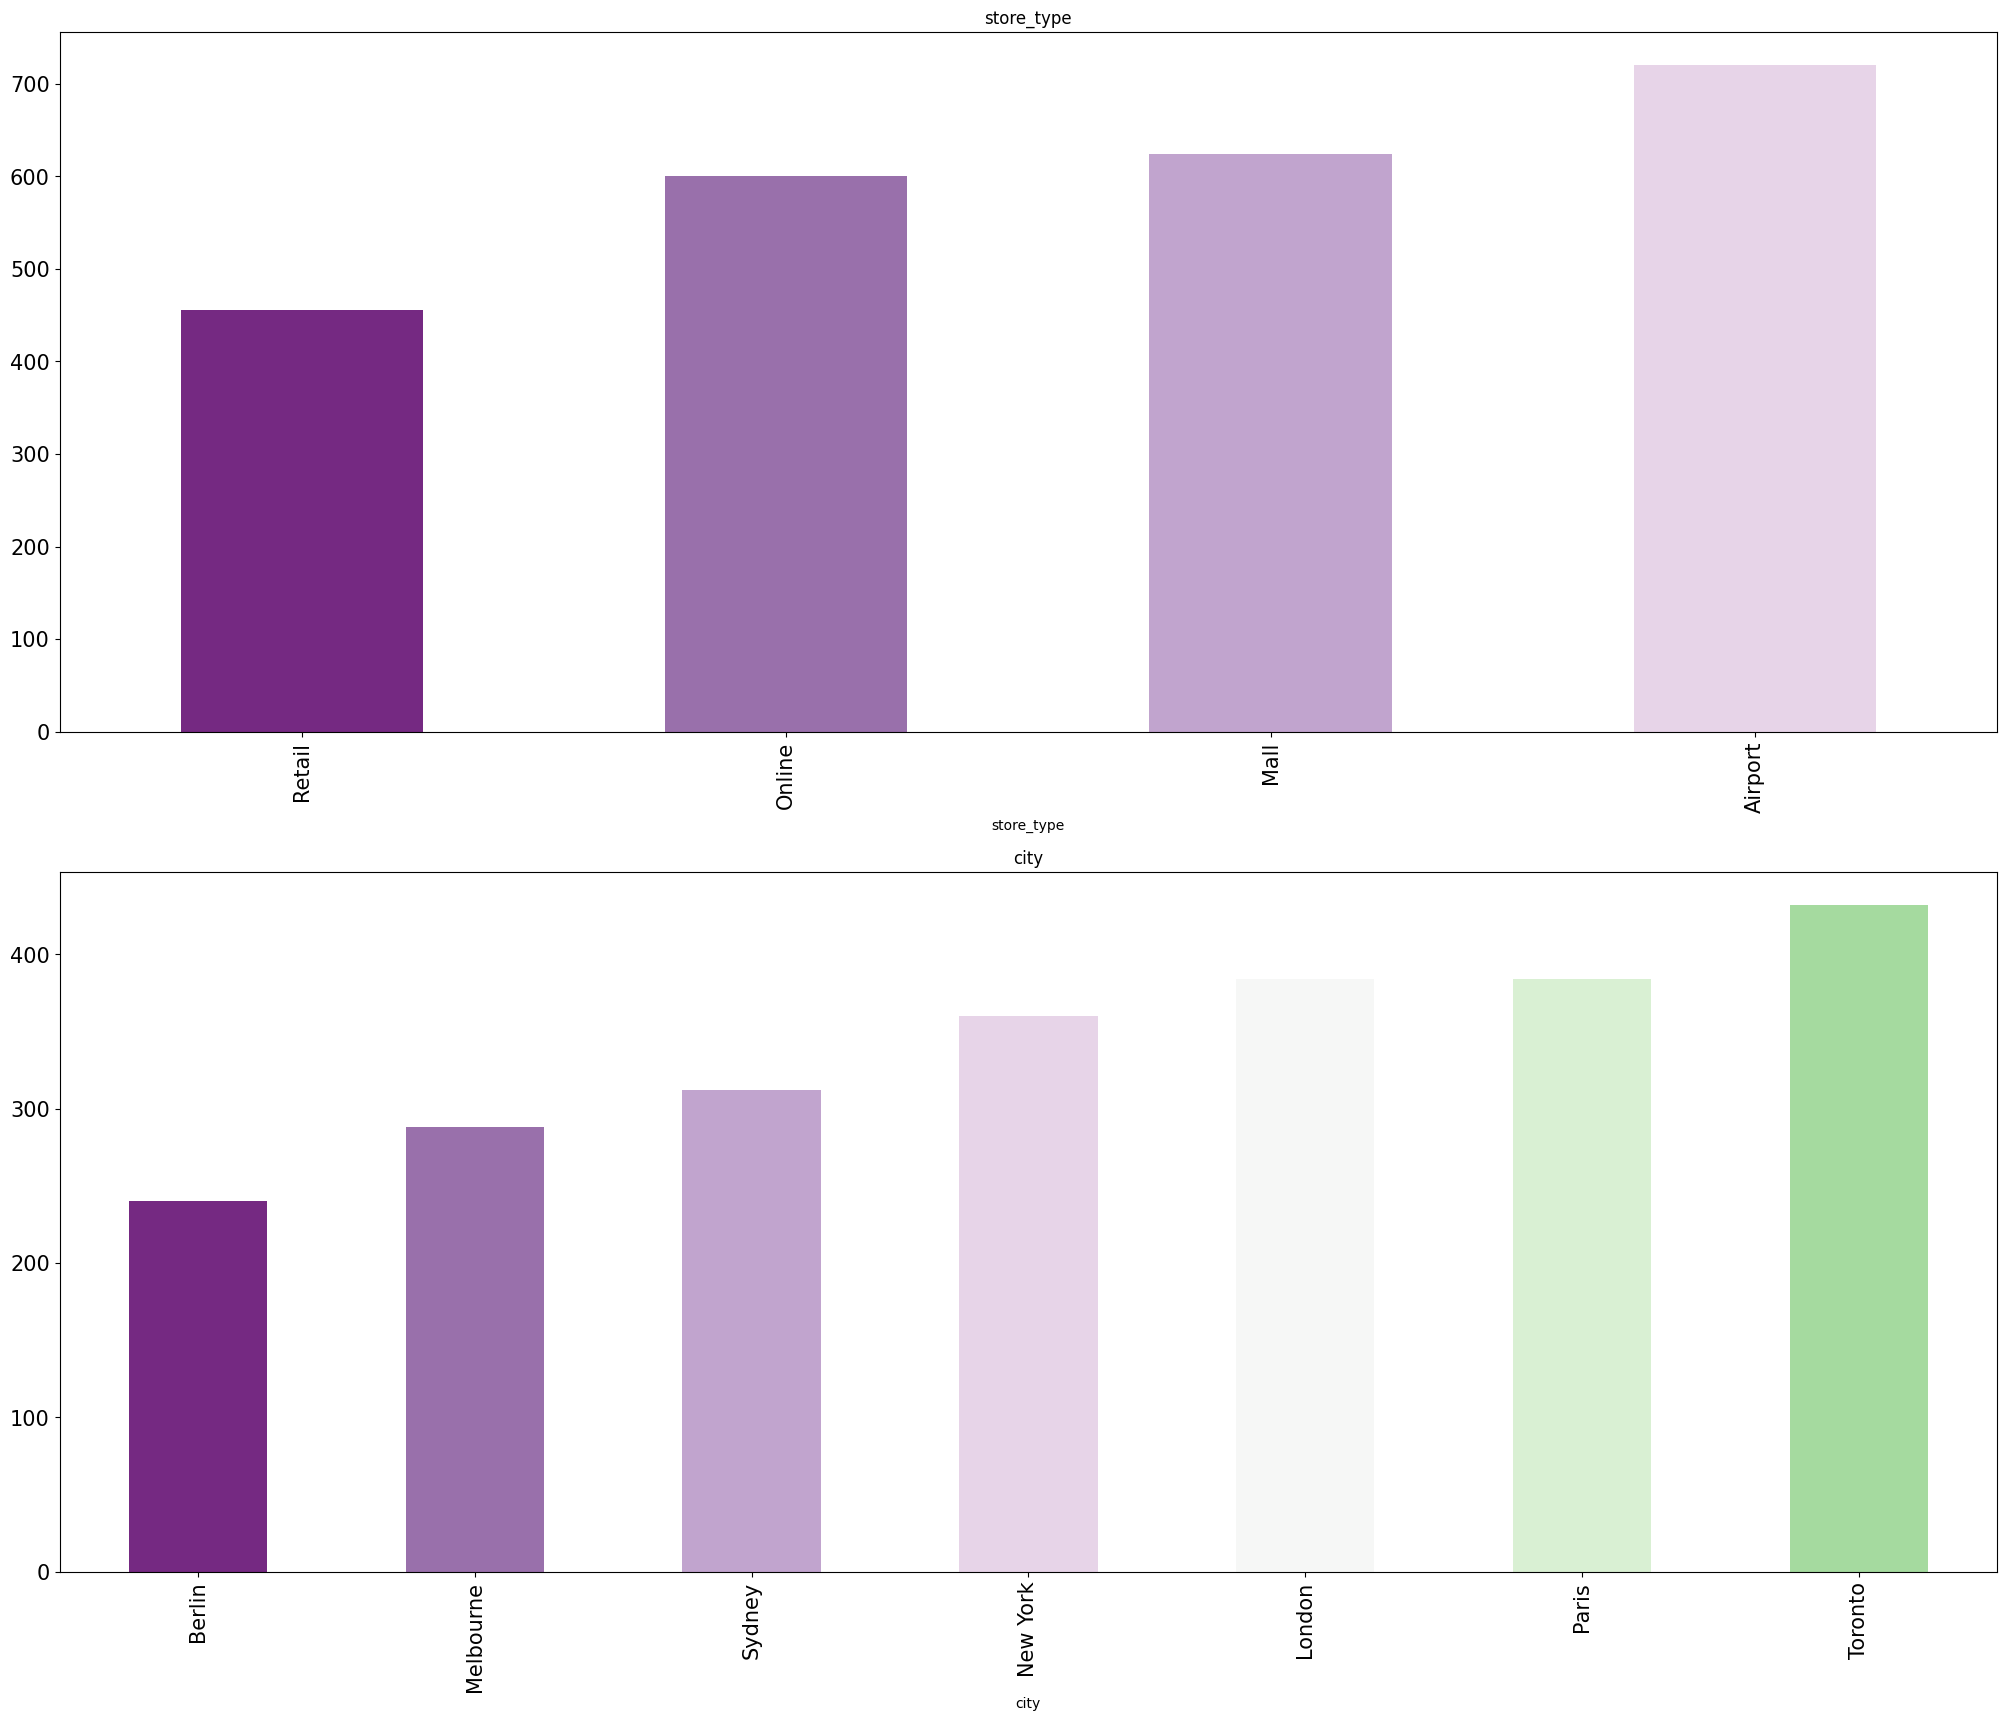

In [104]:
#total values 

obj_cols= ['store_type', 'city']
fig, axes = plt.subplots( nrows=2, figsize= (25,20))
axes = axes.flatten()

for i, col in enumerate(stores_sales[obj_cols]):
    stores_sales[col].value_counts()[::-1].plot(kind= 'bar', ax= axes[i], title= col, fontsize= 15, color= pie_color)

In [100]:
#Strip the stores names
stores_sales['short_store_name'] = stores_sales['store_name'].str.strip().str.split().str[1] + ' ' + stores_sales['store_name'].str.strip().str.split().str[-1]
stores_sales 

,date_order,city,store_type,store_name,total_cust,total_orders,quantity,total_sales,total_cost,profits,short_store_name
0,11-2024,New York,Retail,Chocolate Store 1,416,416,1260,10510.96,6297.77,4213.33,Store 1
1,04-2023,New York,Retail,Chocolate Store 1,418,418,1263,10832.08,6490.57,4341.48,Store 1
2,03-2024,New York,Retail,Chocolate Store 1,434,434,1303,10884.60,6514.40,4370.33,Store 1
3,10-2023,New York,Retail,Chocolate Store 1,412,412,1249,10392.08,6218.00,4174.11,Store 1
4,02-2024,New York,Retail,Chocolate Store 1,397,397,1185,10314.57,6174.25,4140.31,Store 1
...,...,...,...,...,...,...,...,...,...,...,...
2395,11-2024,Toronto,Mall,Chocolate Store 99,450,450,1378,12011.29,7156.71,4854.65,Store 99
2396,03-2024,Toronto,Mall,Chocolate Store 99,389,389,1145,9873.19,5870.37,4002.80,Store 99
2397,09-2024,Toronto,Mall,Chocolate Store 99,423,423,1274,10527.62,6312.85,4214.88,Store 99
2398,02-2023,Toronto,Mall,Chocolate Store 99,358,358,1078,9309.65,5547.93,3761.77,Store 99


In [133]:
retail_store = stores[stores['store_type'] =='Retail' ]
airport_store = stores[stores['store_type'] =='Airport' ]
mall_store = stores[stores['store_type'] =='Mall' ]
online_store = stores[stores['store_type'] =='Online' ]
num_cols = ['total_cust', 'quantity', 'total_sales', 'profits']

retail_sales = retail_store.groupby("short_store_name")[['total_cust', 'quantity', 'total_sales', 'profits']].sum().sort_values(by= 'total_cust').reset_index()
airport_sales = retail_store.groupby("short_store_name")[['total_cust', 'quantity', 'total_sales', 'profits']].sum().sort_values(by= 'total_cust').reset_index()
mall_sales = retail_store.groupby("short_store_name")[['total_cust', 'quantity', 'total_sales', 'profits']].sum().sort_values(by= 'total_cust').reset_index()
online_sales = retail_store.groupby("short_store_name")[['total_cust', 'quantity', 'total_sales', 'profits']].sum().sort_values(by= 'total_cust').reset_index()
#-------------------------------------------------------
# Get top stores
retail_sales = retail_sales.nlargest(10, columns='total_cust')
airport_sales = airport_sales.nlargest(10, 'total_cust')
mall_sales = mall_sales.nlargest(10, 'total_cust')
online_sales = online_sales.nlargest(10, 'total_cust')

sns_colors = sns.color_palette("rocket", 10)


In [152]:
retail_store

,store_type,short_store_name,total_cust,quantity,total_sales,profits
81,Retail,Store 1,10002,29939,254750.31,101878.03
82,Retail,Store 10,9872,29741,252675.80,100983.13
83,Retail,Store 11,9823,29536,251317.15,100733.32
84,Retail,Store 13,10107,30204,255592.82,102263.74
85,Retail,Store 18,9888,29584,250429.21,99988.22
86,Retail,Store 20,9870,29472,252443.31,101029.14
87,Retail,Store 22,10039,30006,256517.06,102721.96
88,Retail,Store 23,9859,29503,250956.55,99899.44
89,Retail,Store 31,9986,29932,253824.34,101711.78
90,Retail,Store 33,10071,30330,257742.84,103373.93


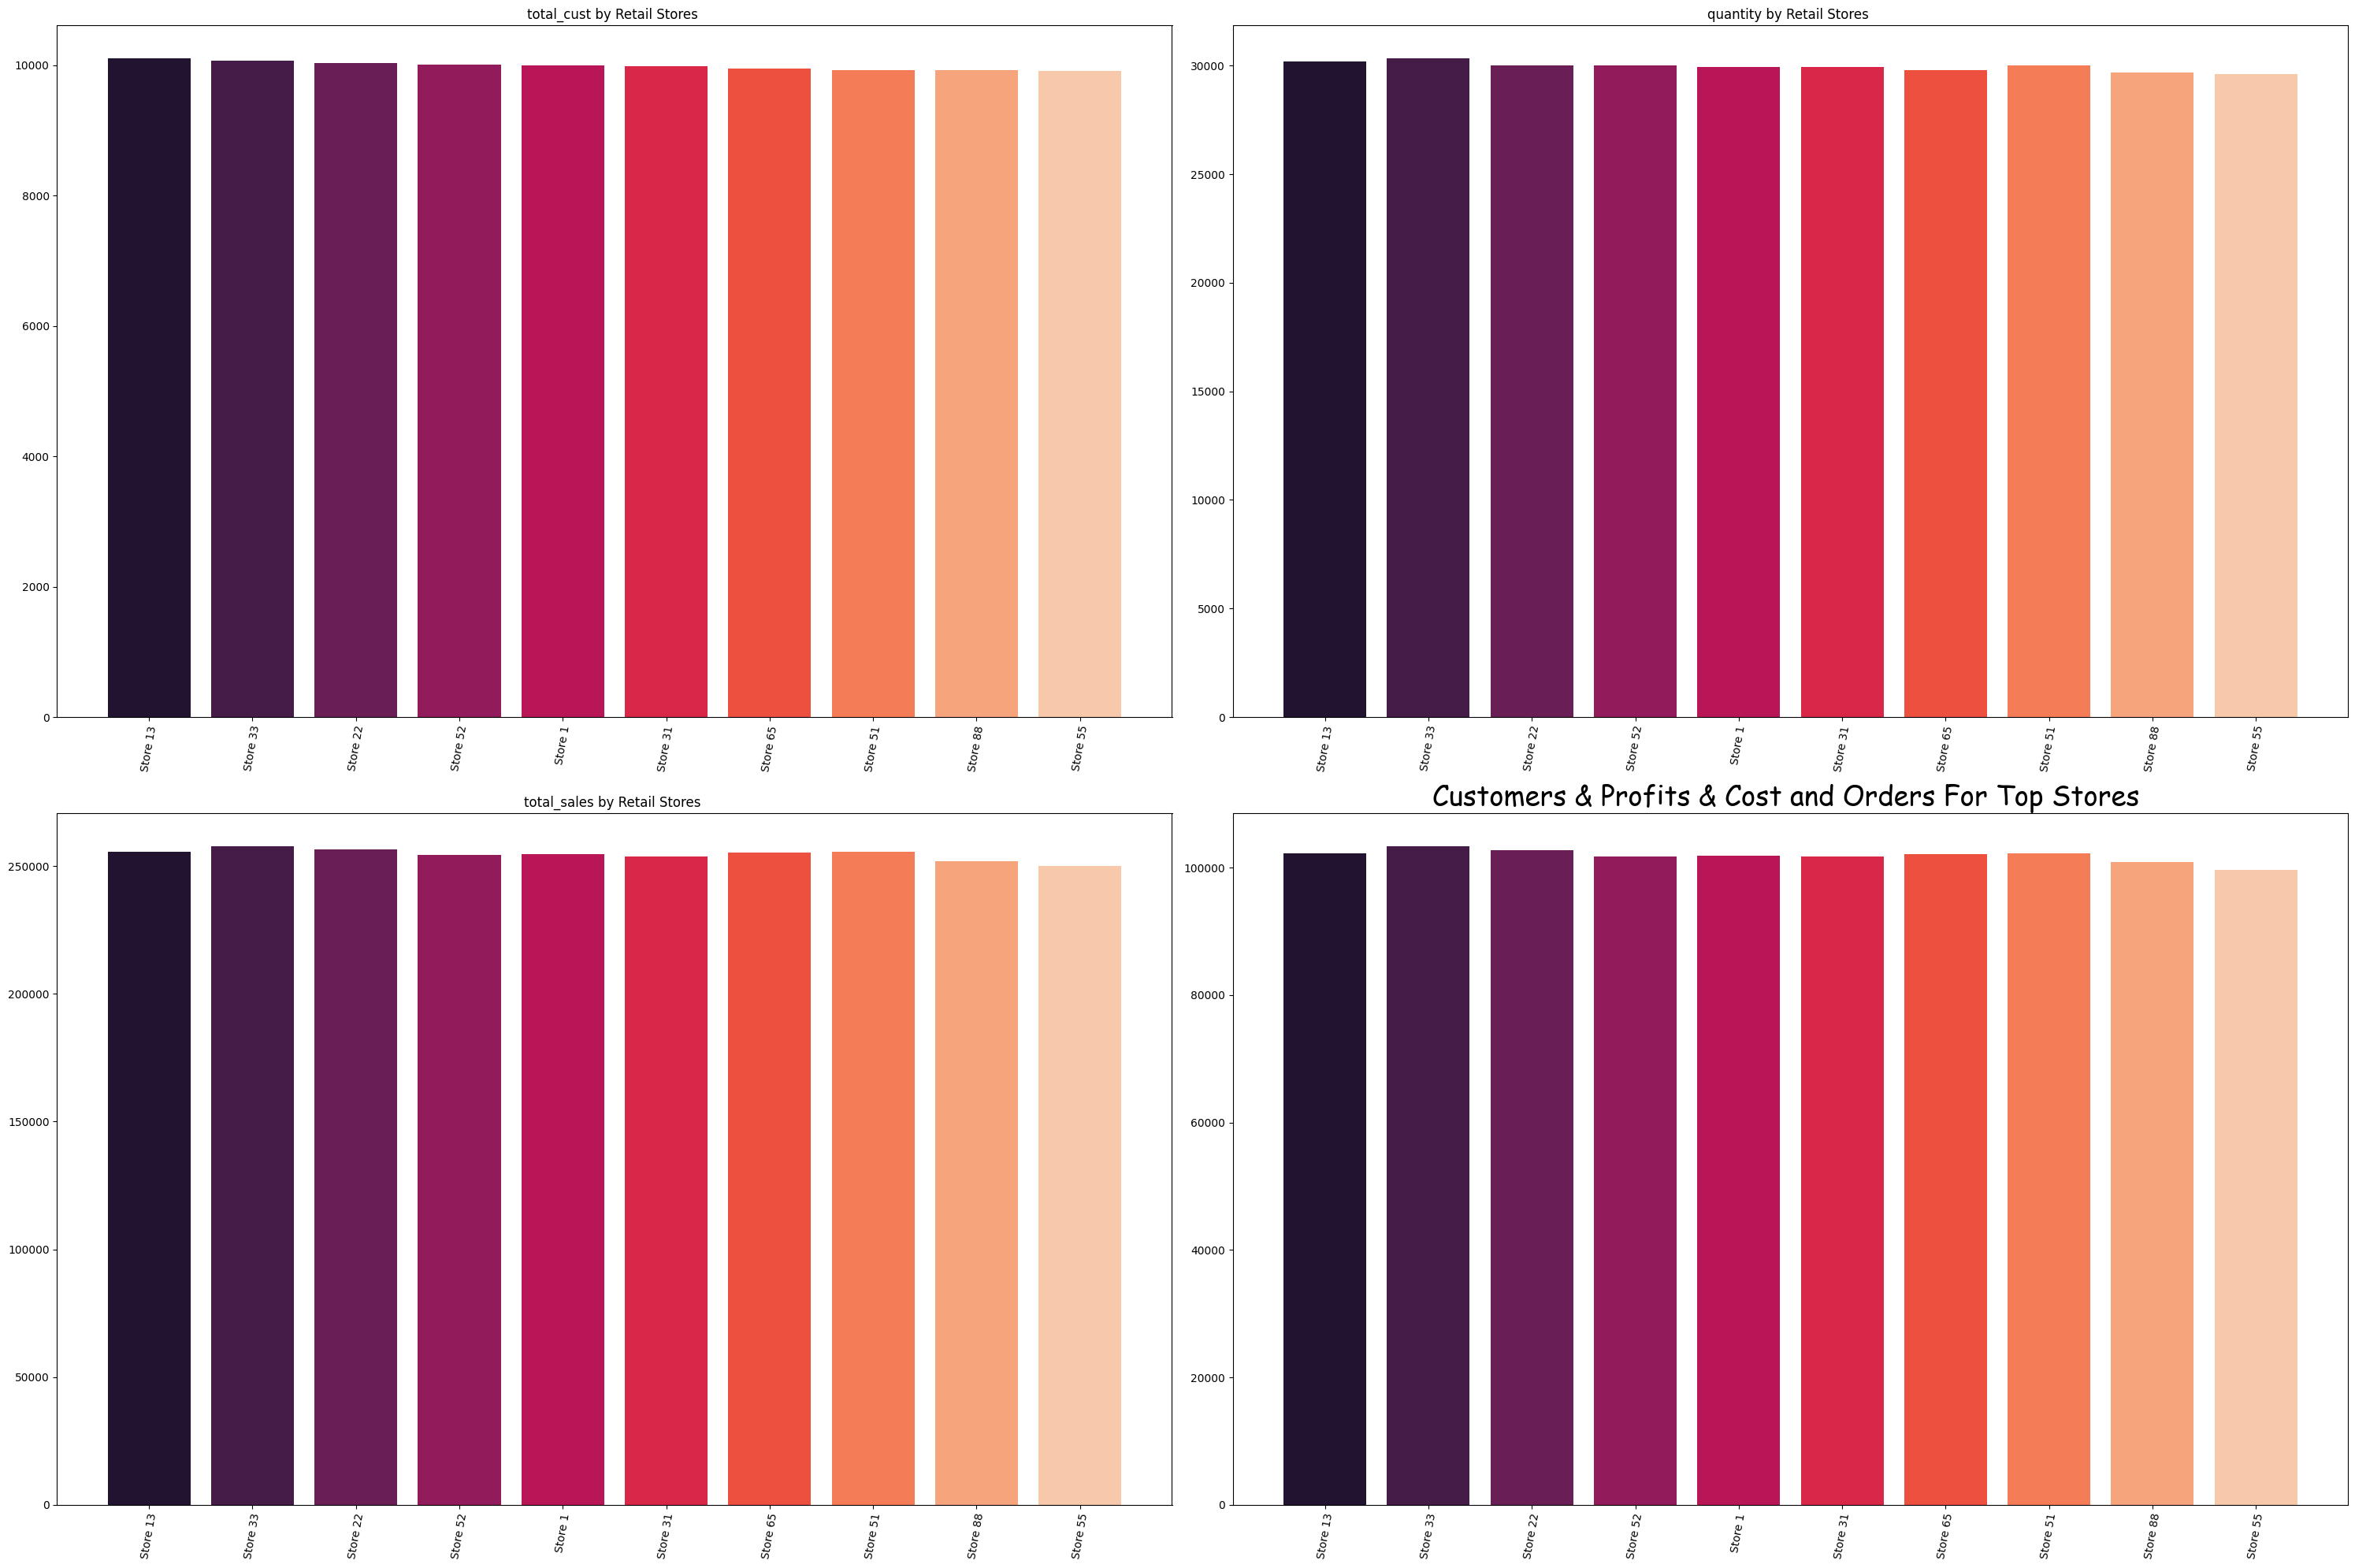

In [ ]:
# Top retail Stores sales
fig, axes = plt.subplots(ncols=2, nrows=2, figsize = (30, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].bar(retail_sales['short_store_name'], retail_sales[col], color = sns_colors)
    axes[i].set_title(f"{col} by Retail Stores ")
    axes[i].tick_params(axis="x", rotation=80) 

plt.tight_layout()
plt.show()   


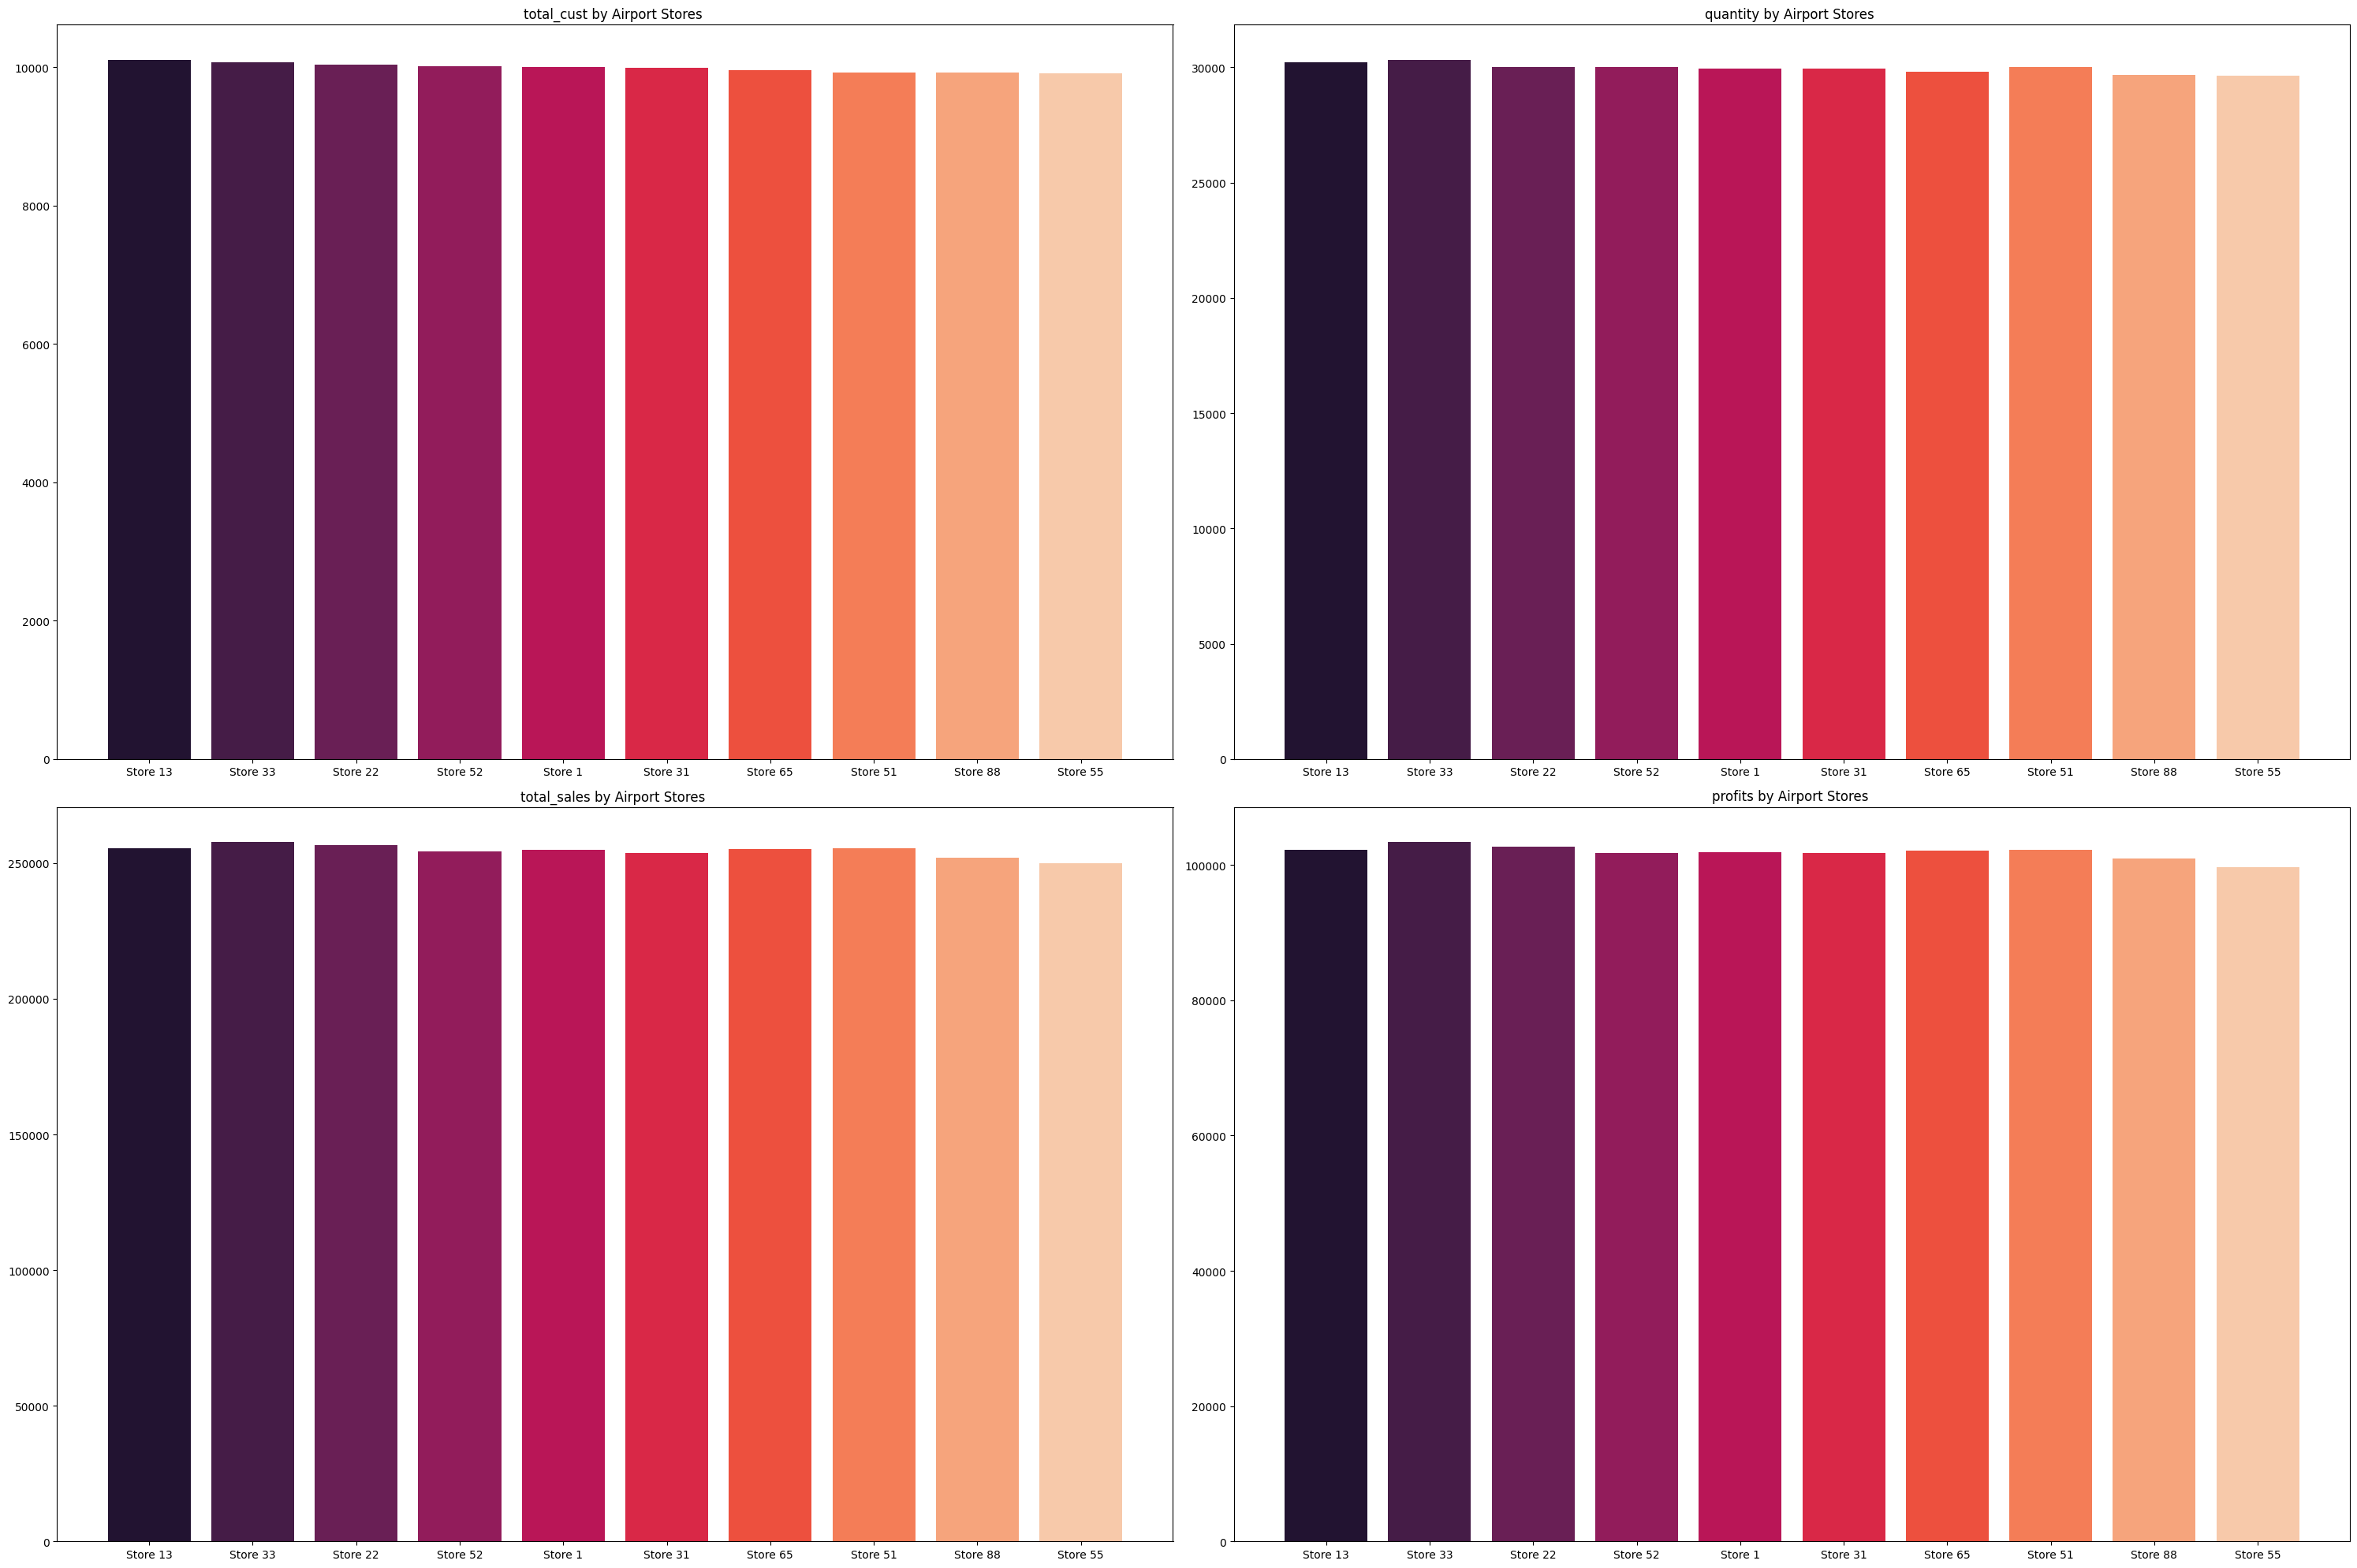

In [140]:
#Airport Sales
fig, axes = plt.subplots(ncols=2, nrows=2, figsize = (30, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].bar(airport_sales['short_store_name'], airport_sales[col], color = sns_colors)
    axes[i].set_title(f"{col} by Airport Stores ")


plt.tight_layout()
plt.show()   

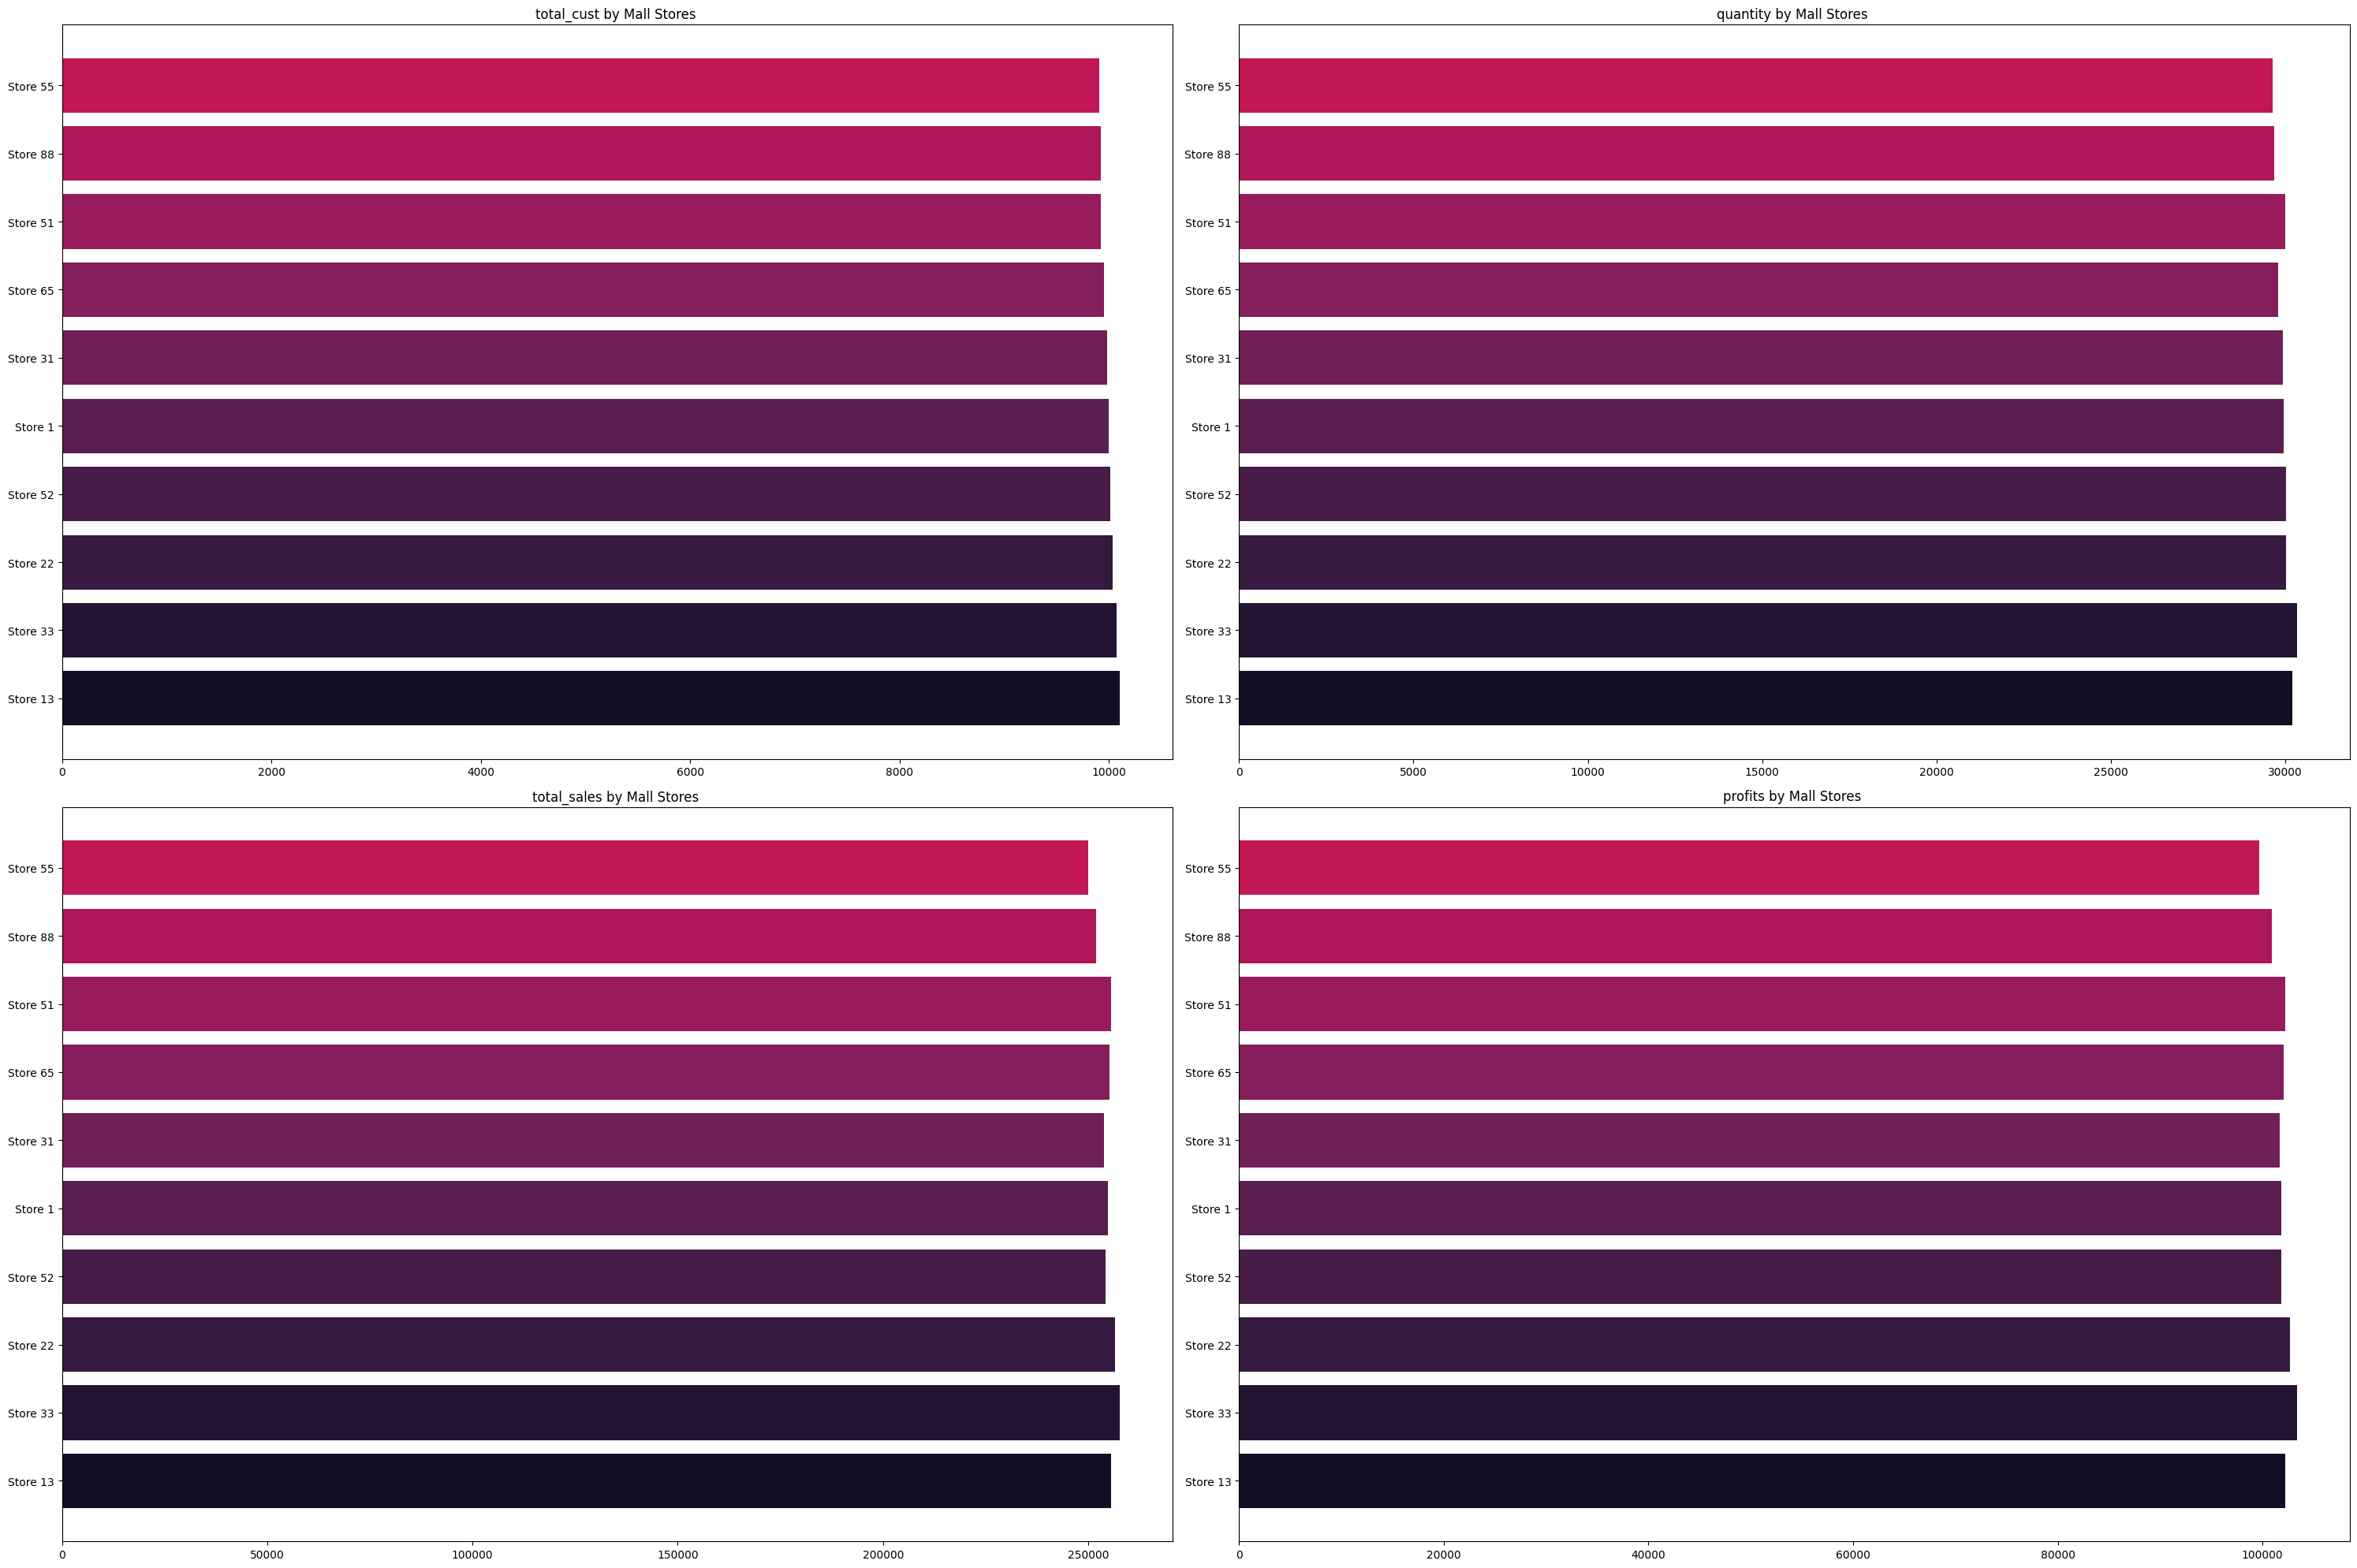

In [141]:
# Mall sales
s_colors = sns.color_palette( 'rocket', 20)
fig, axes = plt.subplots(ncols=2, nrows=2, figsize = (30, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].barh(mall_sales['short_store_name'], mall_sales[col], color = s_colors)
    axes[i].set_title(f"{col} by Mall Stores ")


plt.tight_layout()
plt.show()   

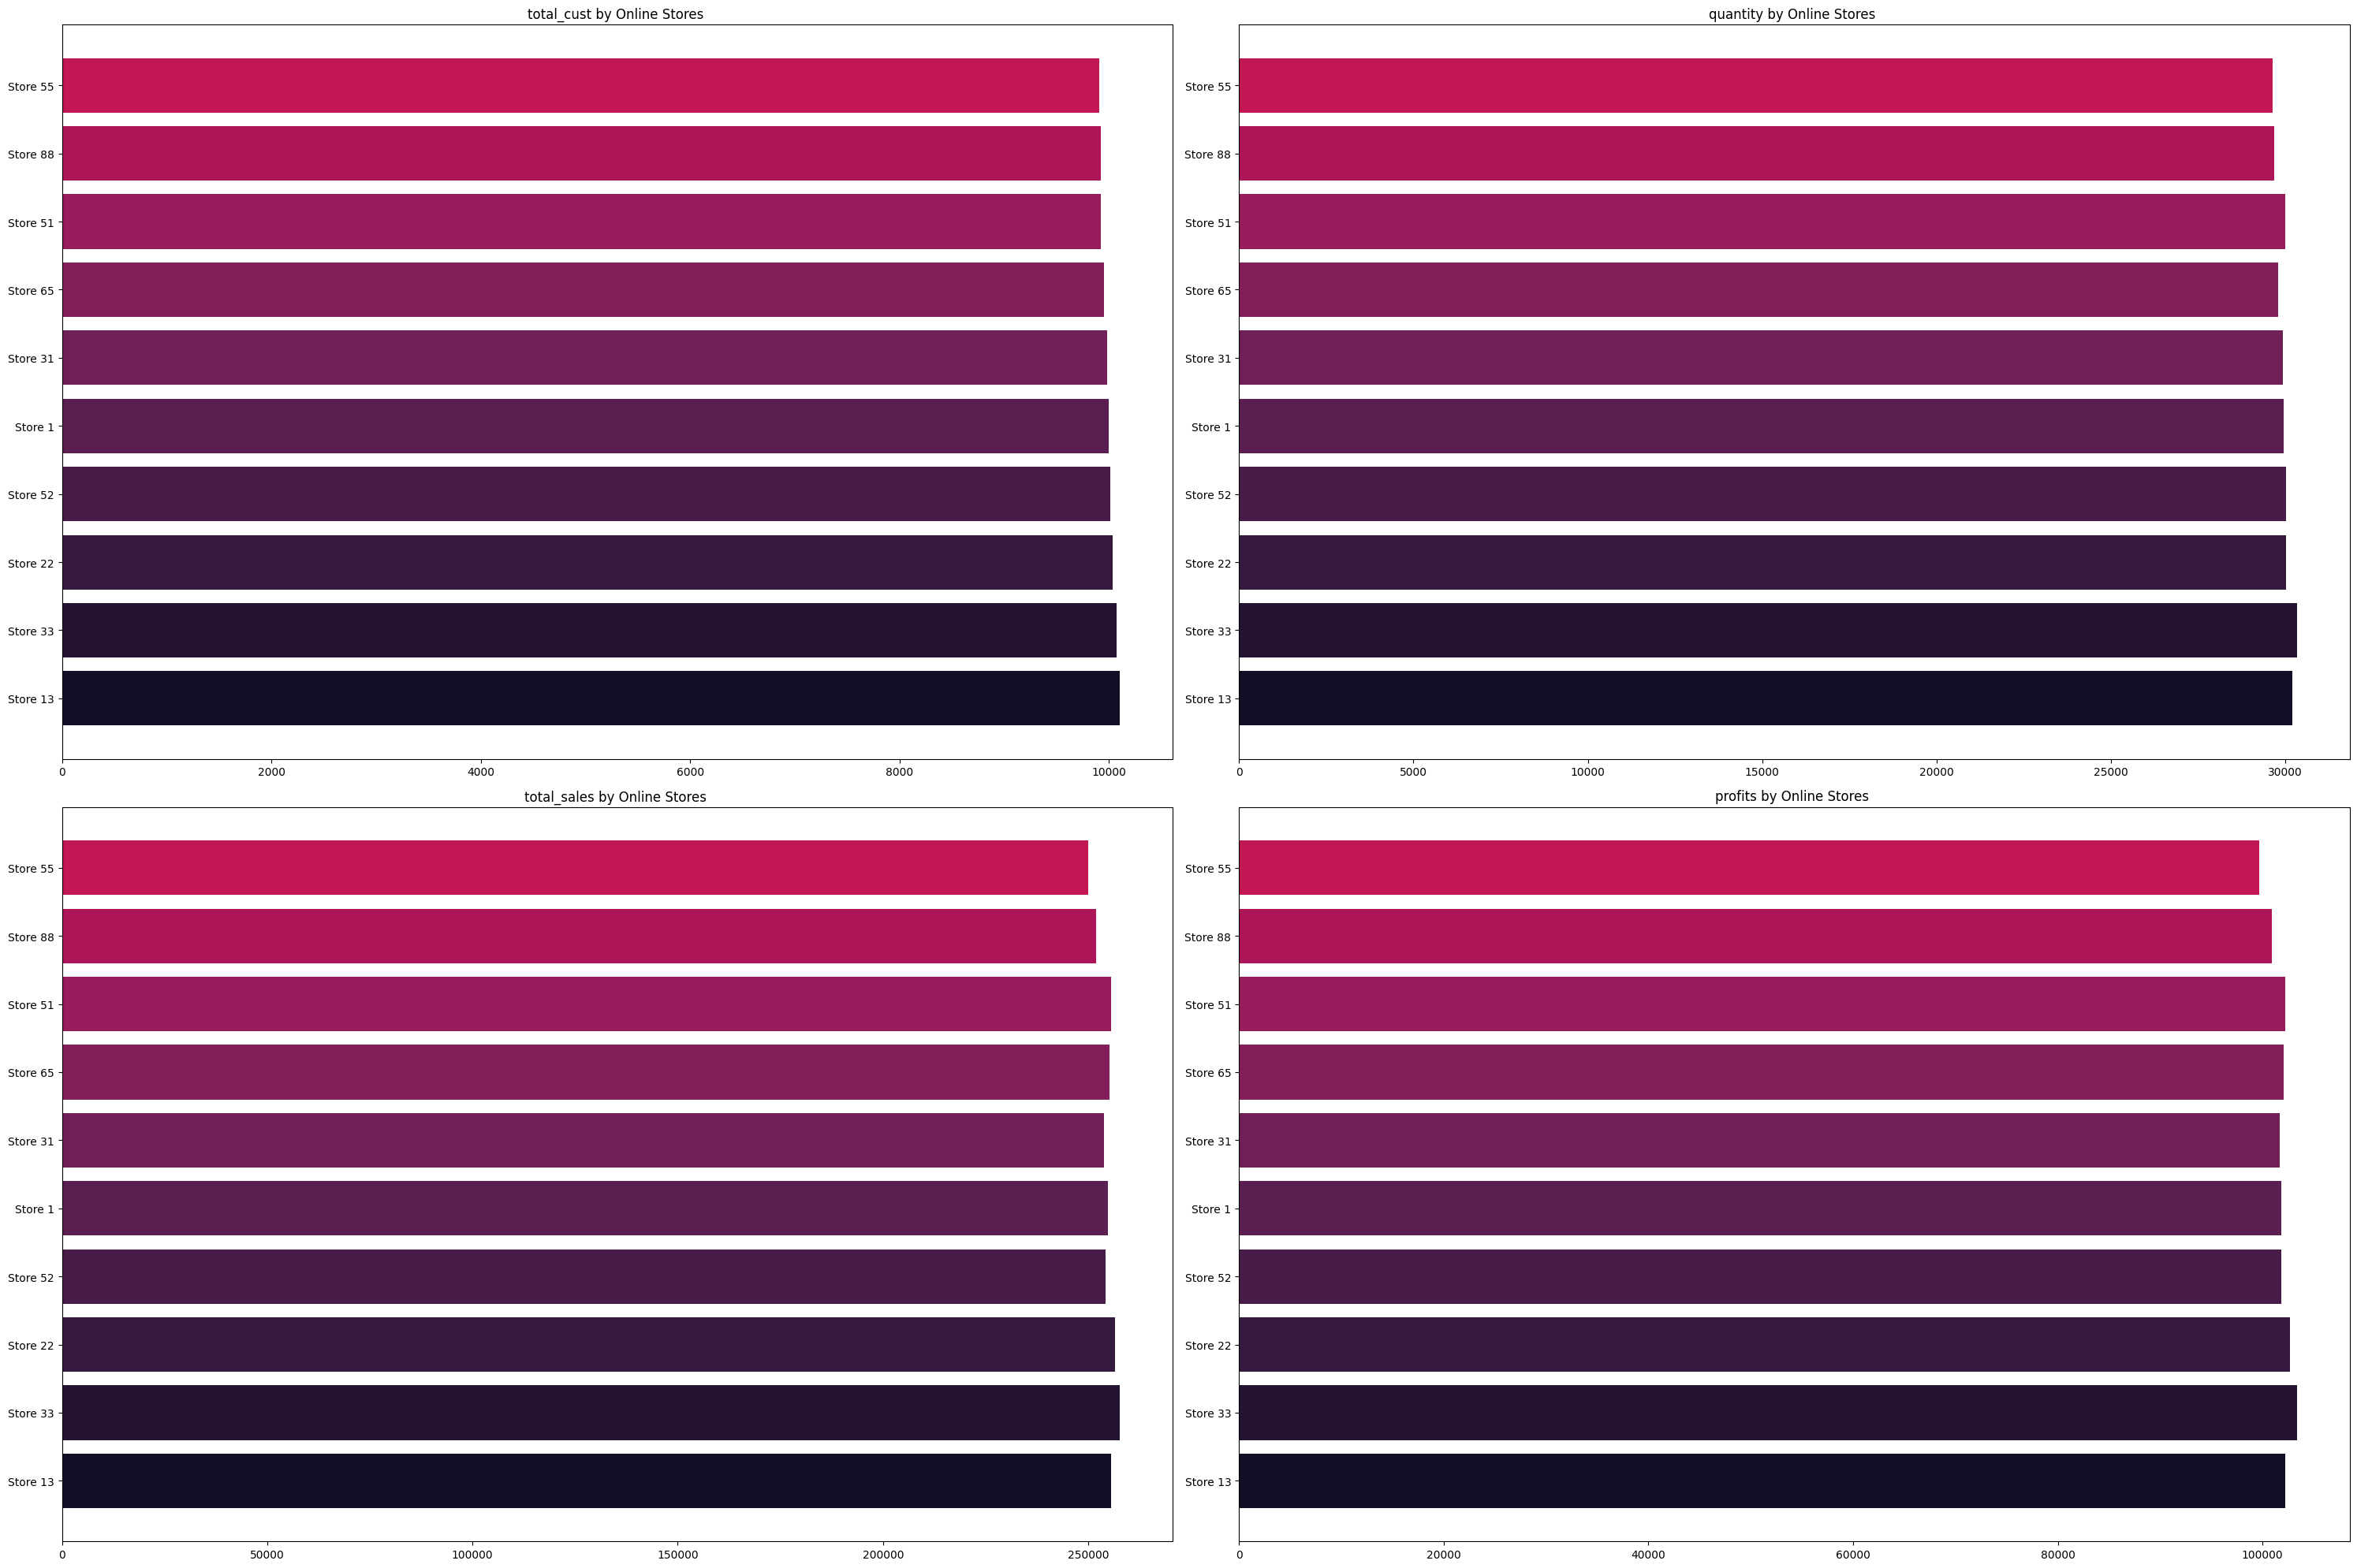

In [142]:
#Online Sales
s_colors = sns.color_palette( 'rocket', 20)
fig, axes = plt.subplots(ncols=2, nrows=2, figsize = (30, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].barh(online_sales['short_store_name'], online_sales[col], color = s_colors)
    axes[i].set_title(f"{col} by Online Stores ")


plt.tight_layout()
plt.show()   

In [ ]:
s_colors = sns.color_palette( 'rocket', 20)
fig, axes = plt.subplots(ncols=2, nrows=2, figsize = (30, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].pie(online_sales['short_store_name'], online_sales[col], color = s_colors, autopct= '%1.1f%%',)
    axes[i].set_title(f"{col} by Online Stores ")


plt.tight_layout()
plt.show()   

<function matplotlib.pyplot.show(close=None, block=None)>

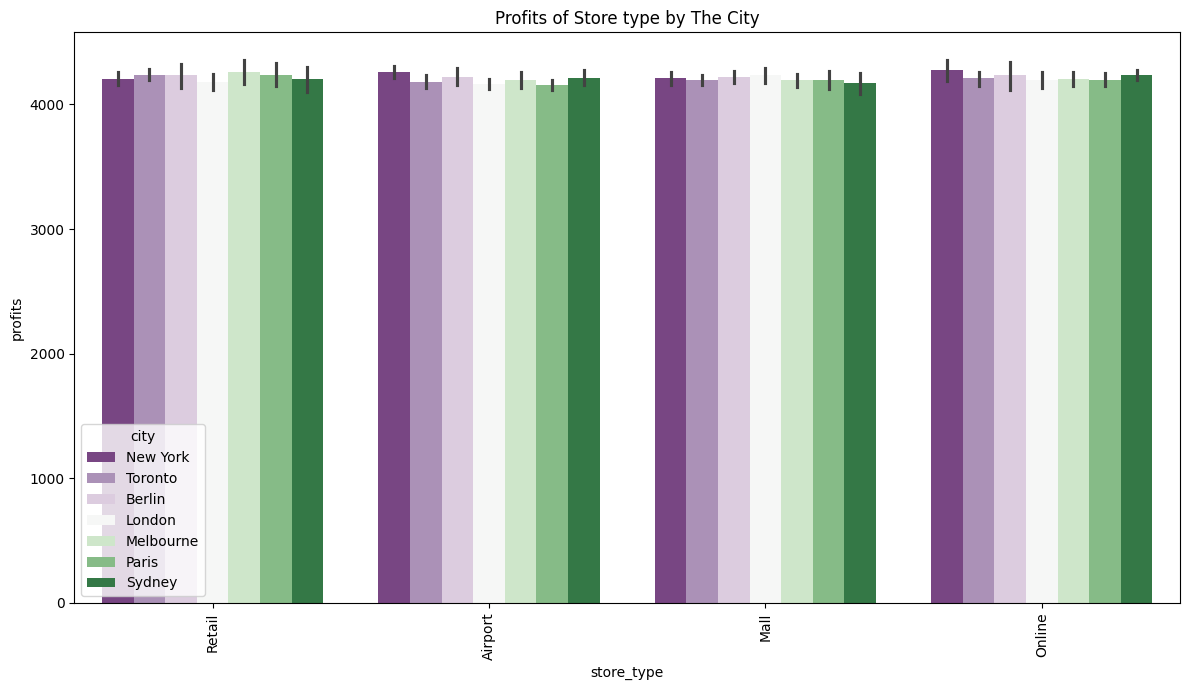

In [ ]:
# sns.barplot(x="engtype", y="price", hue= "drive", palette="husl", data=df)
fig, ax = plt.subplots(figsize=(12,7))
sns.barplot(data=stores_sales,x= 'store_type', y="profits", hue= 'city', palette= 'PRGn')
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
ax.set_title("Profits of Store type by The City")
plt.tight_layout()
plt.show


C:\Users\Fatima\AppData\Local\Temp\ipykernel_28664\3947185628.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  city_values = pd.value_counts(stores_sales['city'].values, sort= False)


<function matplotlib.pyplot.show(close=None, block=None)>

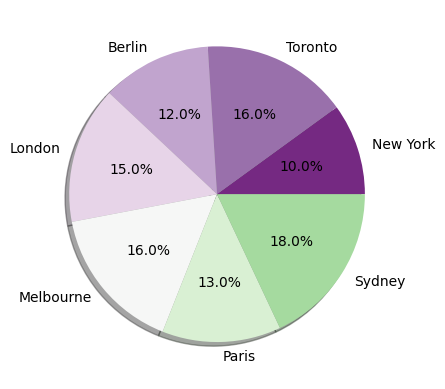

In [153]:
city_values = pd.value_counts(stores_sales['city'].values, sort= False)
lables = stores_sales['city'].unique()
city_values.sort_index(inplace = True)
plt.pie(city_values, labels= lables,colors= pie_color, autopct= '%1.1f%%', shadow= True )
plt.show